#📌 Extracción

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import requests

url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/main/TelecomX_Data.json"

response = requests.get(url)
data = response.json()

df_raw = pd.DataFrame(data)

print(f"✅ Datos cargados correctamente")
print(f"📐 Dimensiones: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")
print(f"\n📋 Columnas:\n{df_raw.columns.tolist()}")

print(f"\n📌 Tipos de datos:")
print(df_raw.dtypes)

print(f"\n📌 Valores nulos por columna:")
print(df_raw.isnull().sum())

# Duplicados: usar solo columna ID para evitar error con dicts anidados
print(f"\n📌 Duplicados por customerID: {df_raw['customerID'].duplicated().sum()}")

# Vista previa segura (convertir a string para mostrar)
df_raw.head()

✅ Datos cargados correctamente
📐 Dimensiones: 7,267 filas × 6 columnas

📋 Columnas:
['customerID', 'Churn', 'customer', 'phone', 'internet', 'account']

📌 Tipos de datos:
customerID    object
Churn         object
customer      object
phone         object
internet      object
account       object
dtype: object

📌 Valores nulos por columna:
customerID    0
Churn         0
customer      0
phone         0
internet      0
account       0
dtype: int64

📌 Duplicados por customerID: 0


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

In [31]:
# ── 1. Normalizar columnas anidadas ─────────────────────────────
df = pd.json_normalize(data)

print(f"📐 Dimensiones tras normalización: {df.shape[0]:,} × {df.shape[1]}")
print(f"\n📋 Columnas disponibles:")
print(df.columns.tolist())

📐 Dimensiones tras normalización: 7,267 × 21

📋 Columnas disponibles:
['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'customer.tenure', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod', 'account.Charges.Monthly', 'account.Charges.Total']


In [32]:
# ── 2. Verificar columnas clave para análisis de evasión ─────────
cols_relevantes = [
    "Churn", "customer.tenure", "account.Contract",
    "account.Charges.Monthly", "account.Charges.Total",
    "account.PaymentMethod", "internet.InternetService",
    "internet.TechSupport", "internet.OnlineSecurity",
    "customer.SeniorCitizen"
]

print("📌 Columnas clave para análisis de evasión:")
for c in cols_relevantes:
    existe = "✅" if c in df.columns else "❌ NO ENCONTRADA"
    print(f"  {existe}  {c}")

📌 Columnas clave para análisis de evasión:
  ✅  Churn
  ✅  customer.tenure
  ✅  account.Contract
  ✅  account.Charges.Monthly
  ✅  account.Charges.Total
  ✅  account.PaymentMethod
  ✅  internet.InternetService
  ✅  internet.TechSupport
  ✅  internet.OnlineSecurity
  ✅  customer.SeniorCitizen


In [33]:
# ── 3. Limpieza ──────────────────────────────────────────────────
print("=" * 50)
print("         🧹 LIMPIEZA DE DATOS")
print("=" * 50)

# Charges.Total puede venir como string vacío → convertir a numérico
col_total = [c for c in df.columns if "Total" in c][0]
df[col_total] = pd.to_numeric(df[col_total], errors="coerce")

# Eliminar filas sin Churn
col_churn = [c for c in df.columns if "Churn" in c or "churn" in c][0]
antes = len(df)
df = df.dropna(subset=[col_churn])
print(f"✅ Filas eliminadas por Churn nulo: {antes - len(df)}")

# Rellenar nulos numéricos con mediana
num_cols = df.select_dtypes(include="number").columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Eliminar duplicados (ya normalizado, sin dicts)
dups = df.duplicated().sum()
df = df.drop_duplicates()
print(f"✅ Duplicados eliminados: {dups}")
print(f"\n📐 Dataset limpio: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"📌 Nulos restantes: {df.isnull().sum().sum()}")

         🧹 LIMPIEZA DE DATOS
✅ Filas eliminadas por Churn nulo: 0
✅ Duplicados eliminados: 0

📐 Dataset limpio: 7,267 filas × 21 columnas
📌 Nulos restantes: 0


In [34]:
# ── 4. Crear columna Cuentas_Diarias ────────────────────────────
col_monthly = [c for c in df.columns if "Monthly" in c][0]
df["Cuentas_Diarias"] = (df[col_monthly] / 30).round(4)
print(f"✅ Columna 'Cuentas_Diarias' creada desde '{col_monthly}'")
print(df[[col_monthly, "Cuentas_Diarias"]].head(5))

✅ Columna 'Cuentas_Diarias' creada desde 'account.Charges.Monthly'
   account.Charges.Monthly  Cuentas_Diarias
0                     65.6           2.1867
1                     59.9           1.9967
2                     73.9           2.4633
3                     98.0           3.2667
4                     83.9           2.7967


In [35]:
# ── 5. Renombrar y estandarizar ──────────────────────────────────
df = df.rename(columns={
    "customerID"                  : "ID_Cliente",
    "Churn"                       : "Evasion",
    "customer.gender"             : "Genero",
    "customer.SeniorCitizen"      : "Adulto_Mayor",
    "customer.Partner"            : "Tiene_Pareja",
    "customer.Dependents"         : "Tiene_Dependientes",
    "customer.tenure"             : "Meses_Contrato",
    "phone.PhoneService"          : "Servicio_Telefono",
    "phone.MultipleLines"         : "Lineas_Multiples",
    "internet.InternetService"    : "Servicio_Internet",
    "internet.OnlineSecurity"     : "Seguridad_Online",
    "internet.OnlineBackup"       : "Respaldo_Online",
    "internet.DeviceProtection"   : "Proteccion_Dispositivo",
    "internet.TechSupport"        : "Soporte_Tecnico",
    "internet.StreamingTV"        : "Streaming_TV",
    "internet.StreamingMovies"    : "Streaming_Peliculas",
    "account.Contract"            : "Tipo_Contrato",
    "account.PaperlessBilling"    : "Factura_Digital",
    "account.PaymentMethod"       : "Metodo_Pago",
    "account.Charges.Monthly"     : "Cargo_Mensual",
    "account.Charges.Total"       : "Cargo_Total",
})

# Codificar Yes/No → 1/0
df["Evasion"] = df["Evasion"].map({"Yes": 1, "No": 0})
for col in ["Tiene_Pareja", "Tiene_Dependientes", "Servicio_Telefono", "Factura_Digital"]:
    if col in df.columns:
        df[col] = df[col].map({"Yes": 1, "No": 0})

print("✅ Estandarización completada")
print(f"\n📋 Columnas finales:\n{df.columns.tolist()}")
df.head(3)

✅ Estandarización completada

📋 Columnas finales:
['ID_Cliente', 'Evasion', 'Genero', 'Adulto_Mayor', 'Tiene_Pareja', 'Tiene_Dependientes', 'Meses_Contrato', 'Servicio_Telefono', 'Lineas_Multiples', 'Servicio_Internet', 'Seguridad_Online', 'Respaldo_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas', 'Tipo_Contrato', 'Factura_Digital', 'Metodo_Pago', 'Cargo_Mensual', 'Cargo_Total', 'Cuentas_Diarias']


,ID_Cliente,Evasion,Genero,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Contrato,Servicio_Telefono,Lineas_Multiples,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Factura_Digital,Metodo_Pago,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
0,0002-ORFBO,0.0,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.1867
1,0003-MKNFE,0.0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,1.9967
2,0004-TLHLJ,1.0,Male,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.4633


#📊 Carga y análisis

In [36]:
# ── Estadísticas descriptivas ────────────────────────────────────
print("=" * 55)
print("     📊 ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 55)

cols_desc = [c for c in ["Meses_Contrato", "Cargo_Mensual",
                          "Cargo_Total", "Cuentas_Diarias"] if c in df.columns]
print(df[cols_desc].describe().round(2).to_string())

print(f"\n📌 Tasa de Evasión global:     {df['Evasion'].mean()*100:.2f}%")
print(f"📌 Total clientes:             {len(df):,}")
print(f"📌 Clientes que se fueron:     {df['Evasion'].sum():,}")
print(f"📌 Clientes que permanecen:    {(df['Evasion']==0).sum():,}")

     📊 ESTADÍSTICAS DESCRIPTIVAS
       Meses_Contrato  Cargo_Mensual  Cargo_Total  Cuentas_Diarias
count         7267.00        7267.00      7267.00          7267.00
mean            32.35          64.72      2279.29             2.16
std             24.57          30.13      2267.18             1.00
min              0.00          18.25        18.80             0.61
25%              9.00          35.42       401.40             1.18
50%             29.00          70.30      1391.00             2.34
75%             55.00          89.88      3778.52             3.00
max             72.00         118.75      8684.80             3.96

📌 Tasa de Evasión global:     26.54%
📌 Total clientes:             7,267
📌 Clientes que se fueron:     1,869.0
📌 Clientes que permanecen:    5,174


/tmp/ipykernel_171/3220387101.py:26: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


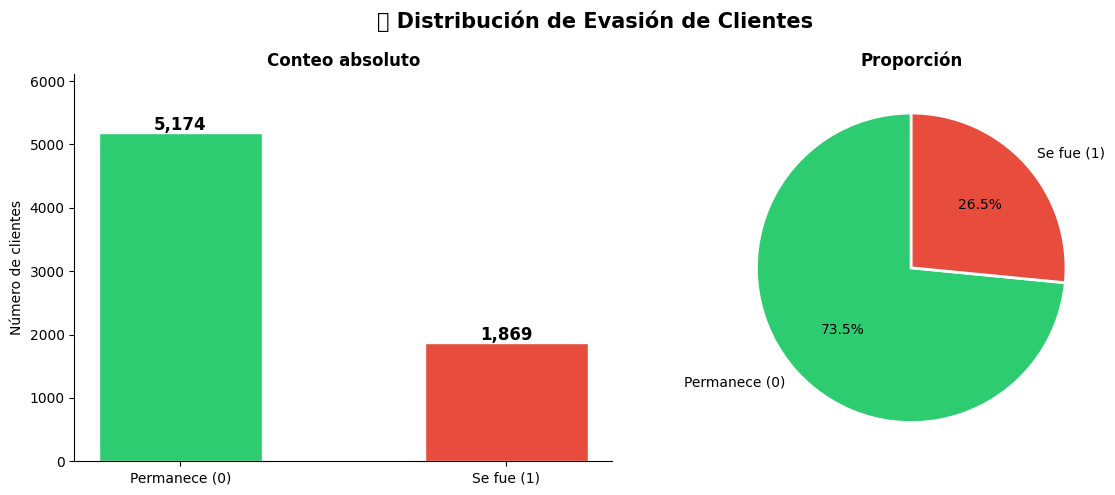

In [37]:
# ── Gráfico 1: Distribución de Evasión ──────────────────────────
conteo = df["Evasion"].value_counts().sort_index()
etiquetas = ["Permanece (0)", "Se fue (1)"]
colores = ["#2ecc71", "#e74c3c"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("📉 Distribución de Evasión de Clientes",
             fontsize=15, fontweight="bold")

bars = axes[0].bar(etiquetas, conteo.values, color=colores,
                   edgecolor="white", width=0.5)
axes[0].set_title("Conteo absoluto", fontweight="bold")
axes[0].set_ylabel("Número de clientes")
axes[0].set_ylim(0, conteo.max() * 1.18)
axes[0].spines[["top", "right"]].set_visible(False)
for bar, val in zip(bars, conteo.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 50,
                 f"{val:,}", ha="center", fontweight="bold", fontsize=12)

axes[1].pie(conteo.values, labels=etiquetas, autopct="%1.1f%%",
            colors=colores, startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Proporción", fontweight="bold")

plt.tight_layout()
plt.show()

/tmp/ipykernel_171/2696465190.py:24: UserWarning: Glyph 128450 (\N{CARD INDEX DIVIDERS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128450 (\N{CARD INDEX DIVIDERS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


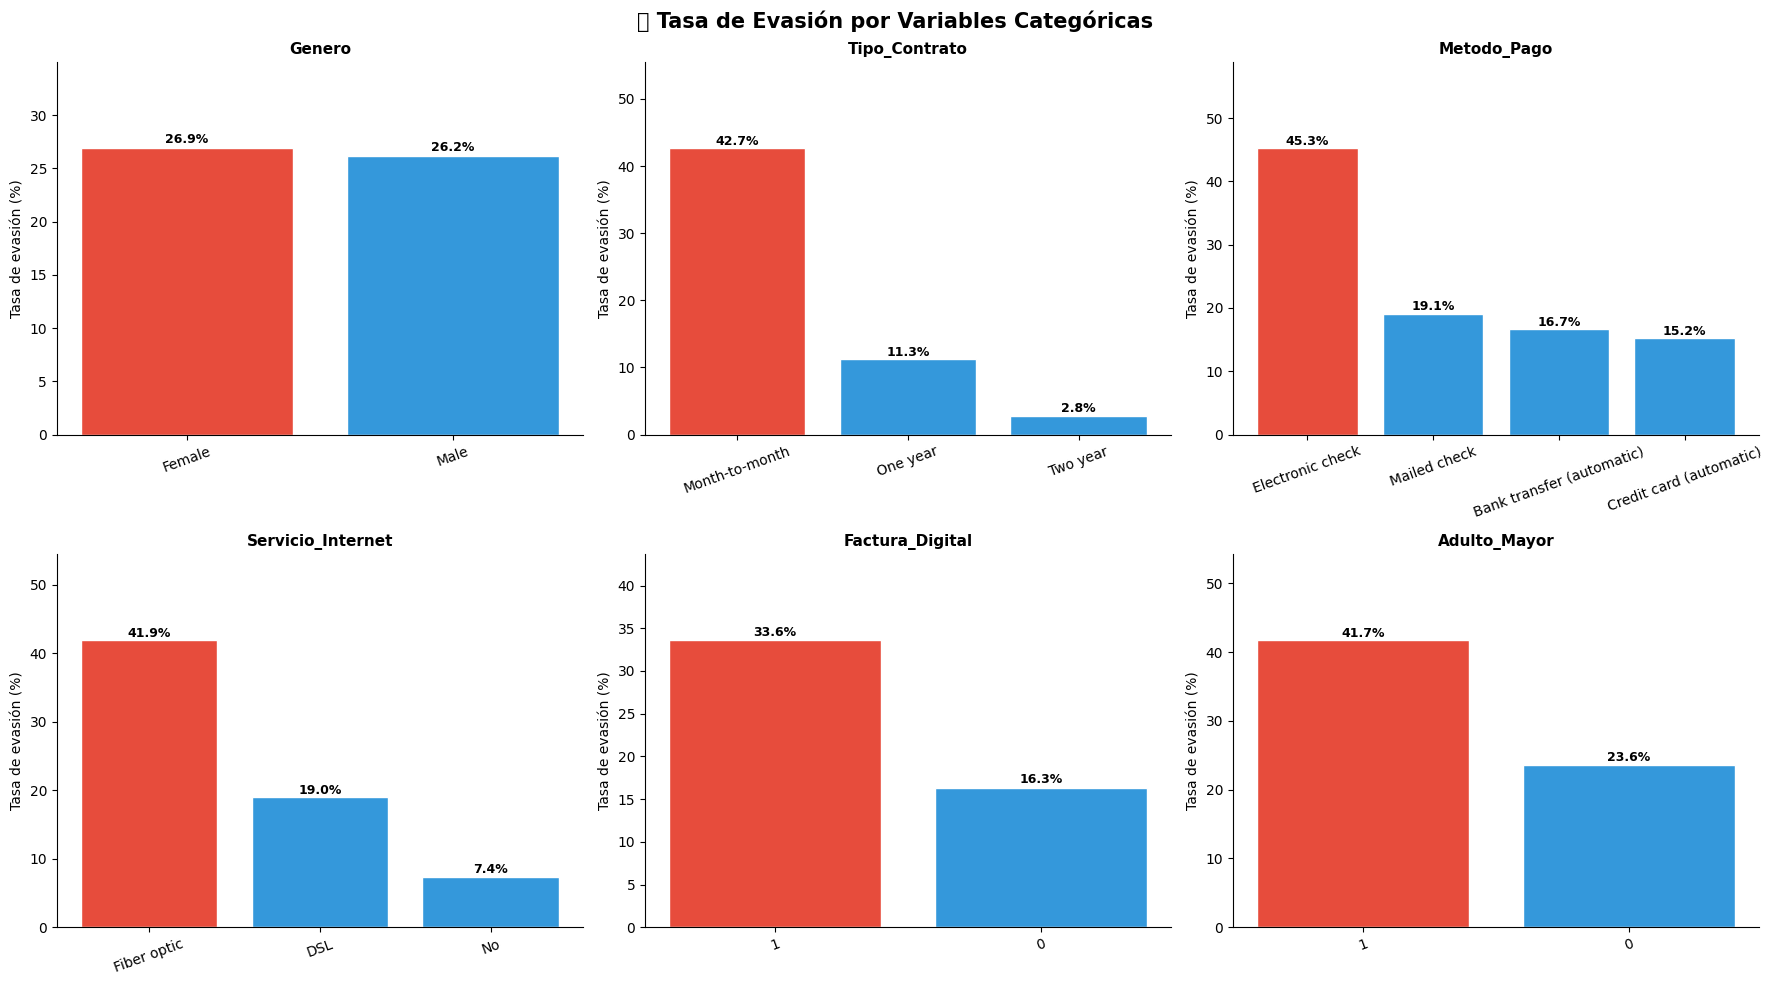

In [38]:
# ── Gráfico 2: Evasión por variables categóricas ─────────────────
cat_cols = ["Genero", "Tipo_Contrato", "Metodo_Pago",
            "Servicio_Internet", "Factura_Digital", "Adulto_Mayor"]
cat_cols = [c for c in cat_cols if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("🗂️ Tasa de Evasión por Variables Categóricas",
             fontsize=15, fontweight="bold")

for ax, col in zip(axes.flatten(), cat_cols):
    tasa = df.groupby(col)["Evasion"].mean().sort_values(ascending=False) * 100
    colores_bar = ["#e74c3c" if v == tasa.max() else "#3498db" for v in tasa.values]
    bars = ax.bar(tasa.index.astype(str), tasa.values,
                  color=colores_bar, edgecolor="white")
    ax.set_title(col, fontweight="bold", fontsize=11)
    ax.set_ylabel("Tasa de evasión (%)")
    ax.set_ylim(0, tasa.max() * 1.3)
    ax.tick_params(axis="x", rotation=20)
    ax.spines[["top", "right"]].set_visible(False)
    for bar, val in zip(bars, tasa.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{val:.1f}%", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

/tmp/ipykernel_171/1047028916.py:20: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


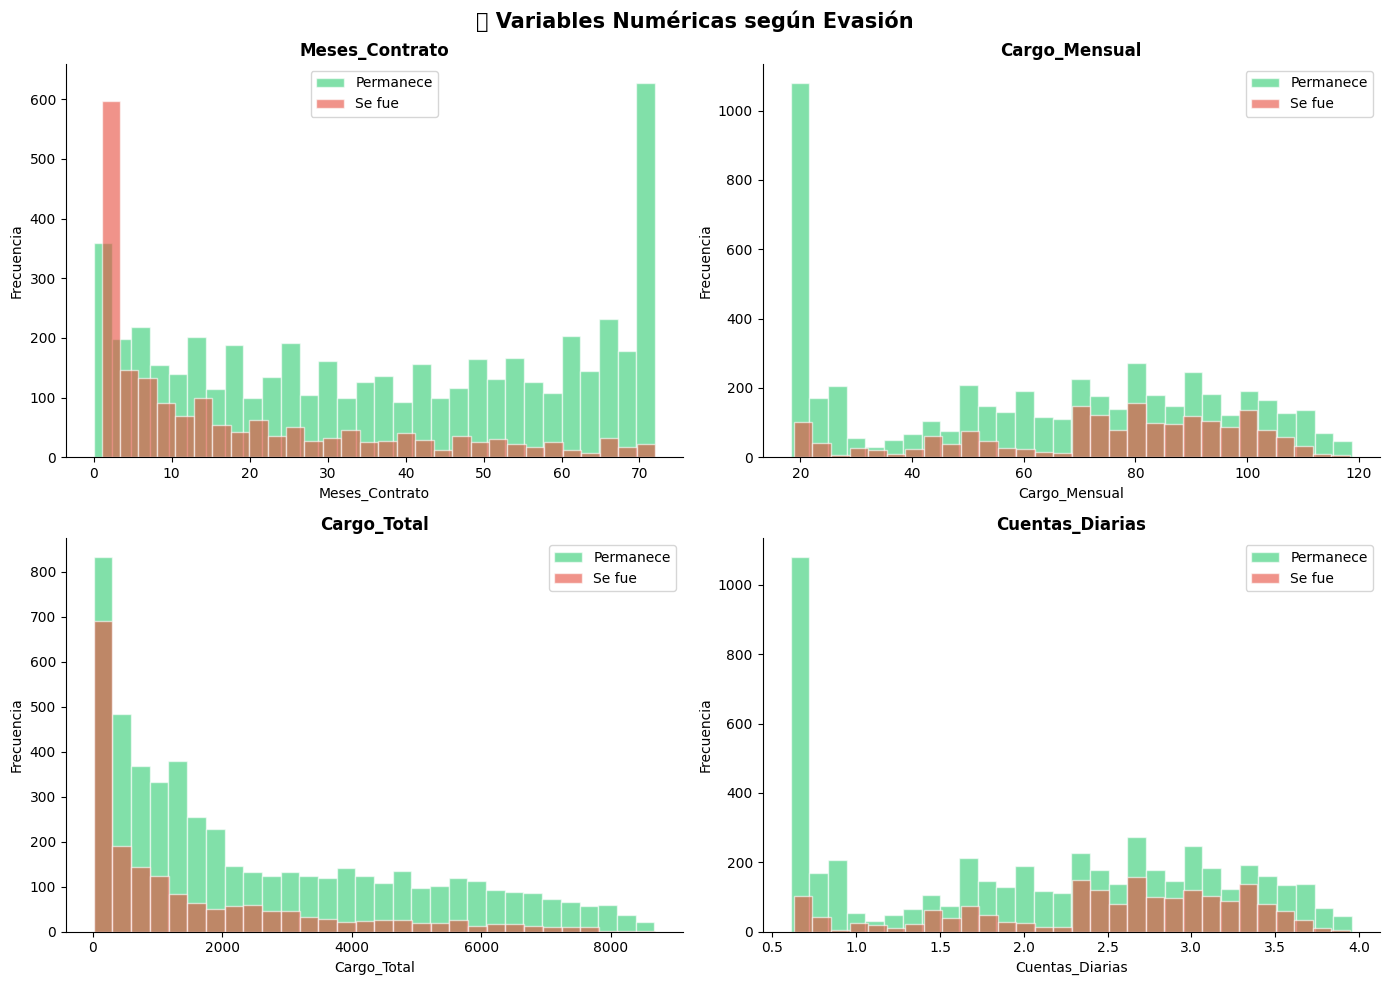

In [39]:
# ── Gráfico 3: Variables numéricas por evasión ───────────────────
num_cols_plot = [c for c in ["Meses_Contrato", "Cargo_Mensual",
                              "Cargo_Total", "Cuentas_Diarias"] if c in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("📈 Variables Numéricas según Evasión",
             fontsize=15, fontweight="bold")

for ax, col in zip(axes.flatten(), num_cols_plot):
    for val, label, color in [(0, "Permanece", "#2ecc71"), (1, "Se fue", "#e74c3c")]:
        ax.hist(df[df["Evasion"] == val][col].dropna(),
                bins=30, alpha=0.6, color=color,
                label=label, edgecolor="white")
    ax.set_title(col, fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Frecuencia")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

/tmp/ipykernel_171/253758535.py:22: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


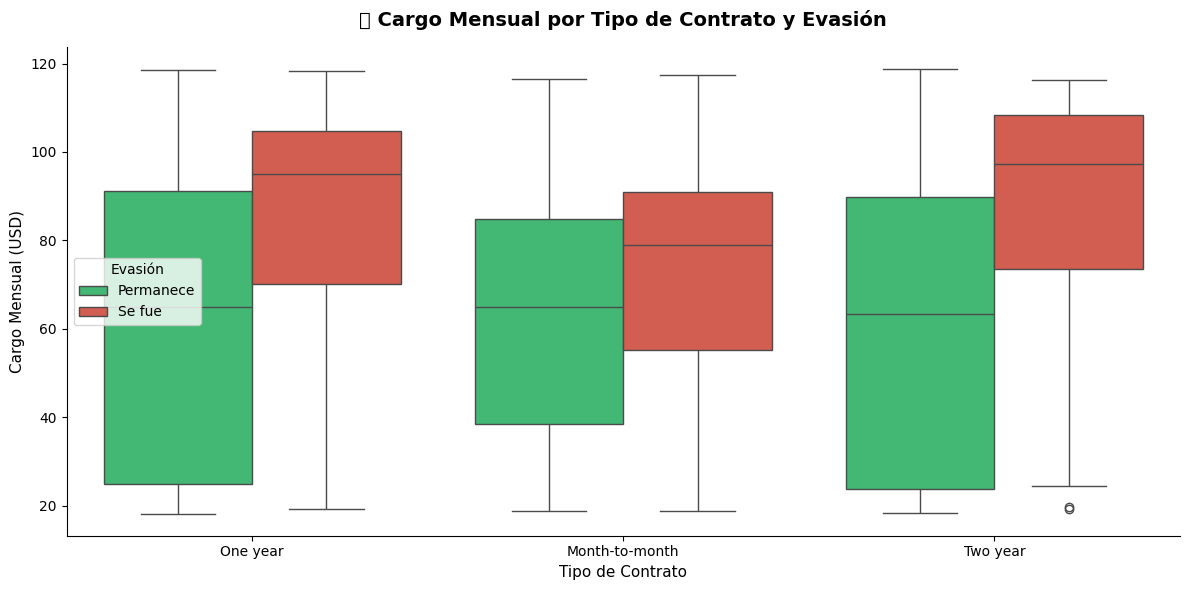

In [40]:
# ── Gráfico 4: Boxplot cargo mensual por contrato y evasión ──────
df_box = df.dropna(subset=["Evasion", "Tipo_Contrato", "Cargo_Mensual"]).copy()
df_box["Evasion_label"] = df_box["Evasion"].astype(int).map({0: "Permanece", 1: "Se fue"})

fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=df_box,
    x="Tipo_Contrato",
    y="Cargo_Mensual",
    hue="Evasion_label",
    palette={"Permanece": "#2ecc71", "Se fue": "#e74c3c"},
    ax=ax
)

ax.set_title("📦 Cargo Mensual por Tipo de Contrato y Evasión",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Tipo de Contrato", fontsize=11)
ax.set_ylabel("Cargo Mensual (USD)", fontsize=11)
ax.legend(title="Evasión")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

/tmp/ipykernel_171/338775718.py:24: UserWarning: Glyph 128268 (\N{ELECTRIC PLUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128268 (\N{ELECTRIC PLUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


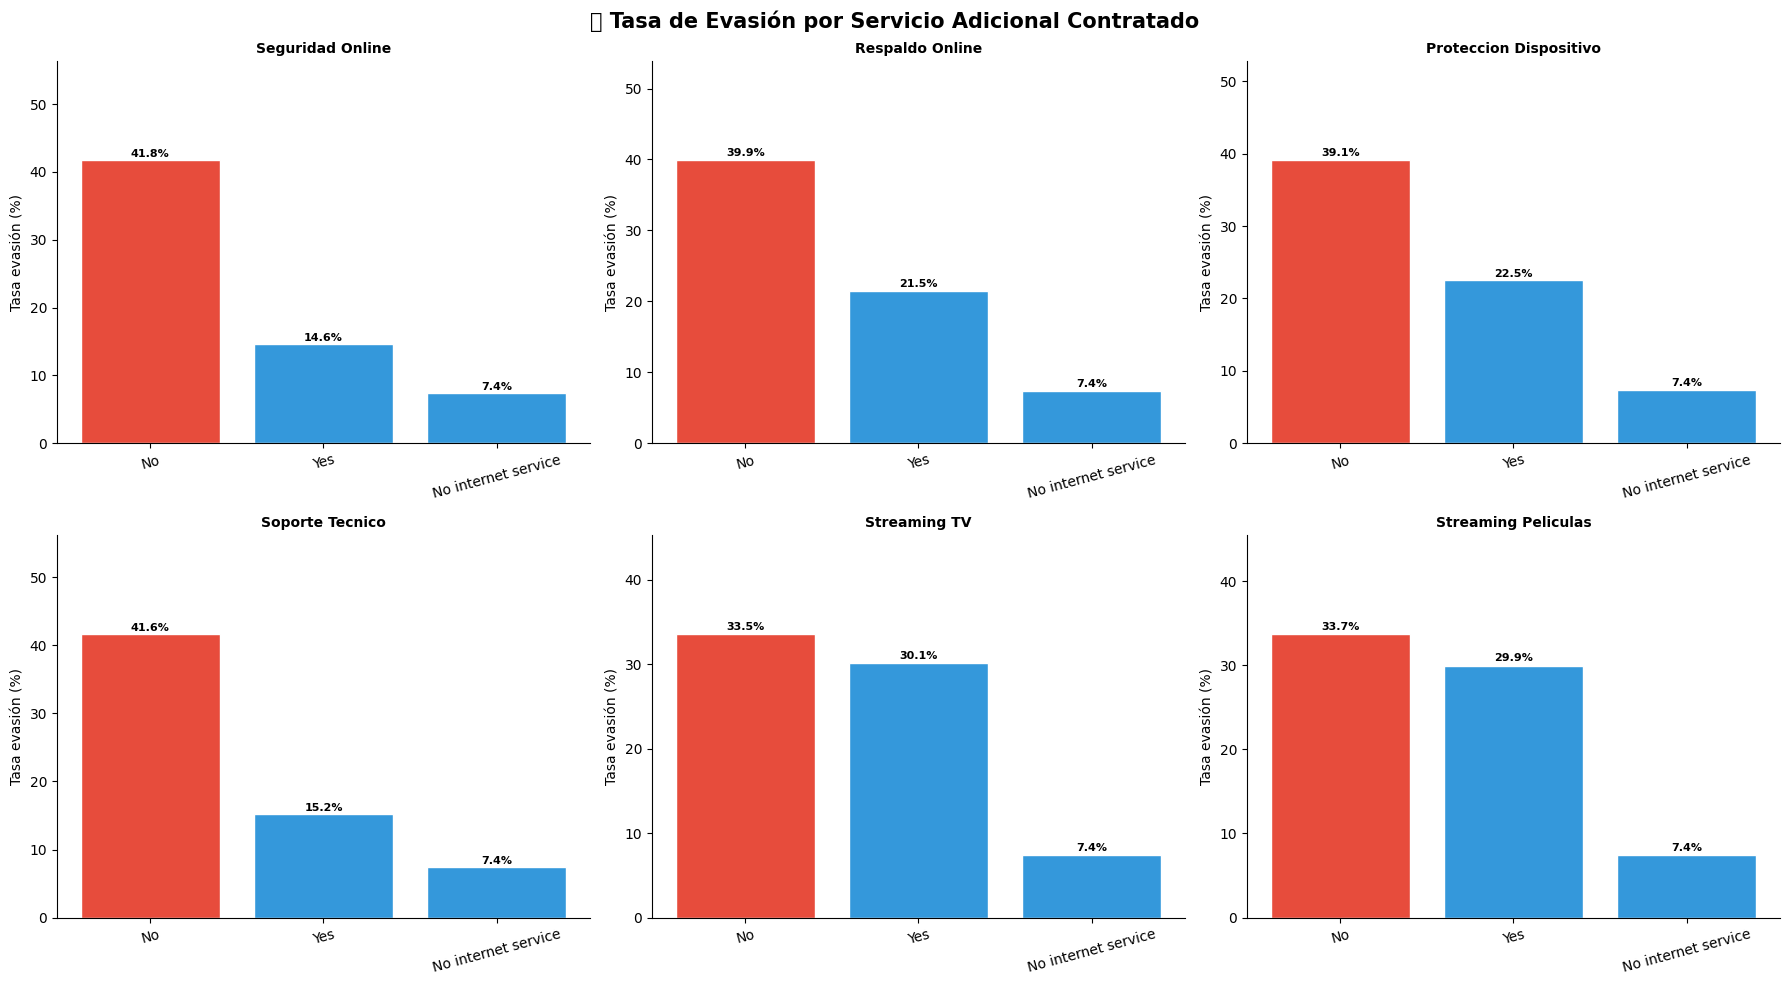

In [41]:
# ── Gráfico 5: Evasión por servicios adicionales ─────────────────
servicios = ["Seguridad_Online", "Respaldo_Online", "Proteccion_Dispositivo",
             "Soporte_Tecnico", "Streaming_TV", "Streaming_Peliculas"]
servicios = [s for s in servicios if s in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("🔌 Tasa de Evasión por Servicio Adicional Contratado",
             fontsize=15, fontweight="bold")

for ax, servicio in zip(axes.flatten(), servicios):
    tasa = df.groupby(servicio)["Evasion"].mean().sort_values(ascending=False) * 100
    colores_s = ["#e74c3c" if v == tasa.max() else "#3498db" for v in tasa.values]
    bars = ax.bar(tasa.index.astype(str), tasa.values,
                  color=colores_s, edgecolor="white")
    ax.set_title(servicio.replace("_", " "), fontweight="bold", fontsize=10)
    ax.set_ylabel("Tasa evasión (%)")
    ax.set_ylim(0, tasa.max() * 1.35)
    ax.tick_params(axis="x", rotation=15)
    ax.spines[["top", "right"]].set_visible(False)
    for bar, val in zip(bars, tasa.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{val:.1f}%", ha="center", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.show()

/tmp/ipykernel_171/1669582364.py:15: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


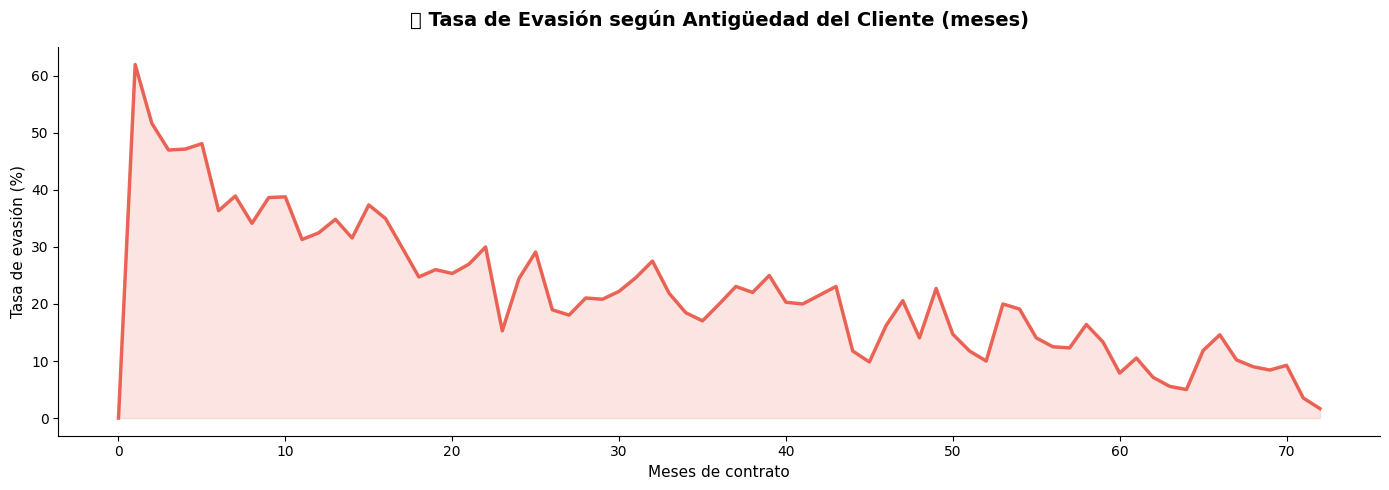

In [42]:
# ── Gráfico 6: Tasa de evasión por antigüedad ────────────────────
evasion_tenure = df.groupby("Meses_Contrato")["Evasion"].mean() * 100

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(evasion_tenure.index, evasion_tenure.values,
        color="#e74c3c", linewidth=2.5, alpha=0.85)
ax.fill_between(evasion_tenure.index, evasion_tenure.values,
                alpha=0.15, color="#e74c3c")

ax.set_title("📅 Tasa de Evasión según Antigüedad del Cliente (meses)",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Meses de contrato", fontsize=11)
ax.set_ylabel("Tasa de evasión (%)", fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

/tmp/ipykernel_171/2924288941.py:10: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


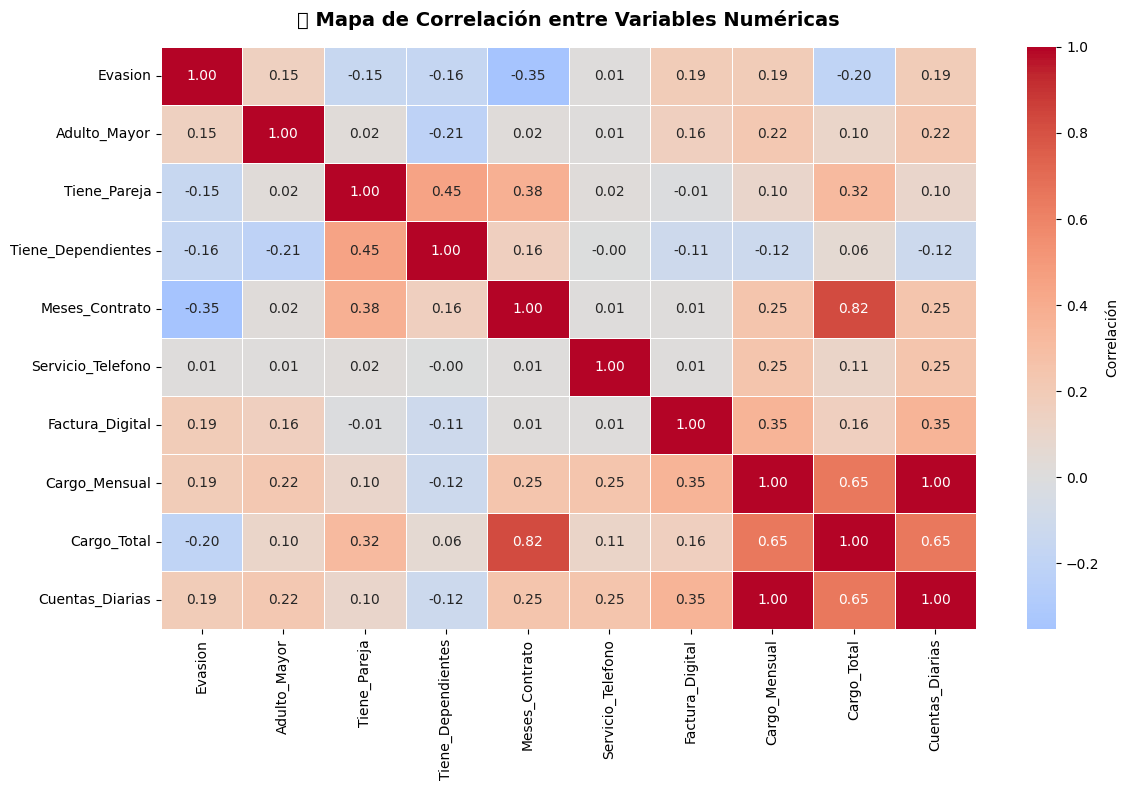

In [43]:
# ── Gráfico 7: Mapa de correlaciones ────────────────────────────
num_df = df.select_dtypes(include="number")

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax,
            cbar_kws={"label": "Correlación"})
ax.set_title("🗺️ Mapa de Correlación entre Variables Numéricas",
             fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

#📄Informe final

In [44]:
tasa_evasion    = df["Evasion"].mean() * 100
total           = len(df)
evadidos        = df["Evasion"].sum()
mejor_contrato  = df.groupby("Tipo_Contrato")["Evasion"].mean().idxmin()
peor_contrato   = df.groupby("Tipo_Contrato")["Evasion"].mean().idxmax()
med_se_fue      = df[df["Evasion"] == 1]["Meses_Contrato"].median()
med_permanece   = df[df["Evasion"] == 0]["Meses_Contrato"].median()
cargo_se_fue    = df[df["Evasion"] == 1]["Cargo_Mensual"].mean()
cargo_permanece = df[df["Evasion"] == 0]["Cargo_Mensual"].mean()

print(f"""
╔══════════════════════════════════════════════════════════════════╗
║        📋 INFORME FINAL — ANÁLISIS DE EVASIÓN TELECOM X         ║
╠══════════════════════════════════════════════════════════════════╣

🔹 INTRODUCCIÓN
   TelecomX enfrenta un problema de evasión (churn) de clientes.
   Este análisis aplica el proceso ETL completo sobre los datos
   de la empresa para identificar patrones y factores de riesgo,
   con el objetivo de orientar estrategias de retención.

🔹 LIMPIEZA Y TRATAMIENTO DE DATOS (ETL)
   • Datos extraídos desde API oficial de Alura en formato JSON.
   • Columnas anidadas expandidas con pd.json_normalize().
   • Charges.Total convertida a numérico (venía como string).
   • Filas con Churn nulo eliminadas; nulos numéricos → mediana.
   • Columna 'Cuentas_Diarias' = Cargo Mensual / 30.
   • Variables renombradas al español y codificadas (Yes→1, No→0).

🔹 ANÁLISIS EXPLORATORIO — HALLAZGOS CLAVE
   • Total clientes analizados:         {total:,}
   • Clientes que abandonaron:          {int(evadidos):,}
   • Tasa de evasión global:            {tasa_evasion:.2f}%

   • Contrato con MAYOR evasión:        {peor_contrato}
   • Contrato con MENOR evasión:        {mejor_contrato}

   • Mediana de meses (se fueron):      {med_se_fue:.0f} meses
   • Mediana de meses (permanecen):     {med_permanece:.0f} meses

   • Cargo mensual promedio (se fueron):   ${cargo_se_fue:.2f}
   • Cargo mensual promedio (permanecen):  ${cargo_permanece:.2f}

🔹 CONCLUSIONES E INSIGHTS
   ✦ Contratos mes a mes concentran la mayor tasa de abandono.
   ✦ Los primeros meses son críticos: clientes nuevos evaden más.
   ✦ Cargos mensuales altos están correlacionados con evasión.
   ✦ Clientes sin soporte técnico o seguridad online evaden más.
   ✦ Ciertos métodos de pago presentan patrones de mayor riesgo.
   ✦ Adultos mayores muestran una tasa de evasión más elevada.

🔹 RECOMENDACIONES ESTRATÉGICAS
   1. Incentivar contratos anuales/bianuales con descuentos.
   2. Crear programas de onboarding en los primeros 12 meses.
   3. Revisar precios para segmentos de cargo mensual elevado.
   4. Ofrecer paquetes de seguridad y soporte como valor añadido.
   5. Diseñar campañas específicas para adultos mayores y
      clientes sin dependientes (perfiles de mayor riesgo).
   6. Analizar y mejorar la experiencia en métodos de pago
      con mayor tasa de abandono.

╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║        📋 INFORME FINAL — ANÁLISIS DE EVASIÓN TELECOM X         ║
╠══════════════════════════════════════════════════════════════════╣

🔹 INTRODUCCIÓN
   TelecomX enfrenta un problema de evasión (churn) de clientes.
   Este análisis aplica el proceso ETL completo sobre los datos
   de la empresa para identificar patrones y factores de riesgo,
   con el objetivo de orientar estrategias de retención.

🔹 LIMPIEZA Y TRATAMIENTO DE DATOS (ETL)
   • Datos extraídos desde API oficial de Alura en formato JSON.
   • Columnas anidadas expandidas con pd.json_normalize().
   • Charges.Total convertida a numérico (venía como string).
   • Filas con Churn nulo eliminadas; nulos numéricos → mediana.
   • Columna 'Cuentas_Diarias' = Cargo Mensual / 30.
   • Variables renombradas al español y codificadas (Yes→1, No→0).

🔹 ANÁLISIS EXPLORATORIO — HALLAZGOS CLAVE
   • Total clientes analizados:         7,267
   • Clientes que abandona